# ACP — Indicateurs d'audit de serveurs
**Datacamp II — Master 2 GI 2025-2026**

Les données (`serveurs_audit_acp_m2.csv`) sont **synthétiques** : aucune mesure opérationnelle réelle ni diagnostic de sécurité ne peut être déduit des résultats obtenus ici.

Ce notebook suit les questions du sujet une à une.

## Imports et configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 20)

## Question 1 — Import et inspection des données

**Objectif :** charger le CSV, vérifier sa forme, les types de colonnes, l'absence de doublons/valeurs manquantes, et regarder la dispersion de chaque variable. Puis séparer :
- les **variables actives** (les 11 indicateurs quantitatifs) qui entreront dans l'ACP,
- l'**identifiant** (`serveur_id`),
- le **segment externe** (`segment_synthetique`).

**Pourquoi exclure les deux dernières colonnes de l'ACP ?**
- `serveur_id` est un simple identifiant textuel, sans contenu numérique interprétable : l'inclure n'apporterait qu'un bruit arbitraire, pas une variance porteuse de sens.
- `segment_synthetique` est une **étiquette externe** (catégorielle), construite indépendamment des mesures et destinée à être comparée *a posteriori* aux résultats de l'ACP. L'ACP est une méthode non supervisée : si on l'incluait comme variable active, on risquerait de faire de la projection en partie *sur* l'étiquette qu'on veut ensuite utiliser pour valider/interpréter les axes — un raisonnement circulaire.

In [2]:
df = pd.read_csv("../data/serveurs_audit_acp_m2.csv")

print("Forme (lignes, colonnes) :", df.shape)
print()
print("Types de colonnes :")
print(df.dtypes)

Forme (lignes, colonnes) : (160, 13)

Types de colonnes :
serveur_id                      str
cpu_pct                     float64
ram_pct                     float64
trafic_mbps                 float64
latence_ms                  float64
tentatives_intrusion        float64
ports_exposes               float64
vulnerabilites_ouvertes     float64
jours_depuis_correctif      float64
disponibilite_pct           float64
temps_retablissement_min    float64
sauvegardes_reussies_pct    float64
segment_synthetique             str
dtype: object


In [3]:
print("Doublons (lignes strictement identiques) :", df.duplicated().sum())
print("Doublons sur serveur_id :", df["serveur_id"].duplicated().sum())
print()
print("Valeurs manquantes par colonne :")
print(df.isna().sum())

Doublons (lignes strictement identiques) : 0
Doublons sur serveur_id : 0

Valeurs manquantes par colonne :
serveur_id                  0
cpu_pct                     0
ram_pct                     0
trafic_mbps                 0
latence_ms                  0
tentatives_intrusion        0
ports_exposes               0
vulnerabilites_ouvertes     0
jours_depuis_correctif      0
disponibilite_pct           0
temps_retablissement_min    0
sauvegardes_reussies_pct    0
segment_synthetique         0
dtype: int64


In [4]:
# Dispersion des variables quantitatives : moyenne, écart-type, min/max, quartiles
df.describe().T

,count,mean,std,min,25%,50%,75%,max
cpu_pct,160.0,56.224375,18.315332,12.58,42.6750,55.710,70.1025,99.00
ram_pct,160.0,60.024563,15.746280,22.40,48.0525,61.025,71.8525,91.44
trafic_mbps,160.0,312.304438,106.582883,58.66,227.6975,312.155,391.2900,558.09
latence_ms,160.0,47.790813,11.857124,20.74,38.4975,48.505,55.2075,76.35
tentatives_intrusion,160.0,23.961750,10.147135,0.00,16.3550,24.795,29.9875,50.18
ports_exposes,160.0,11.671813,4.095899,0.00,8.8625,11.520,14.6275,21.16
vulnerabilites_ouvertes,160.0,9.094875,3.671080,0.00,6.5975,9.280,11.6275,18.38
jours_depuis_correctif,160.0,35.168687,11.980270,1.77,27.1950,35.670,44.7225,63.99
disponibilite_pct,160.0,98.443750,0.589812,97.19,97.9950,98.410,98.8600,99.98
temps_retablissement_min,160.0,43.289375,11.882445,9.43,35.8325,41.650,51.7800,77.70


In [5]:
# Séparation identifiant / segment externe / variables actives
id_col = df["serveur_id"]
segment_col = df["segment_synthetique"]

X = df.drop(columns=["serveur_id", "segment_synthetique"])

print("Variables actives retenues pour l'ACP :")
print(list(X.columns))
print()
print("Répartition du segment externe :")
print(segment_col.value_counts())

Variables actives retenues pour l'ACP :
['cpu_pct', 'ram_pct', 'trafic_mbps', 'latence_ms', 'tentatives_intrusion', 'ports_exposes', 'vulnerabilites_ouvertes', 'jours_depuis_correctif', 'disponibilite_pct', 'temps_retablissement_min', 'sauvegardes_reussies_pct']

Répartition du segment externe :
segment_synthetique
intermediaire    67
peu_expose       49
expose           44
Name: count, dtype: int64


## Question 2 — Covariance ou corrélation, matrice de corrélation

**Covariance ou corrélation ?** Dans `df.describe()` (Question 1), les écarts-types vont de **0.59** (`disponibilite_pct`, en %) à **106.6** (`trafic_mbps`, en Mbps) — un rapport de ~180, et les unités sont hétérogènes (%, ms, Mbps, jours, compteurs...).
- Une ACP sur **covariance** utiliserait les variances brutes : `trafic_mbps` écraserait le premier axe seulement parce que son échelle est plus grande, pas parce qu'elle est plus informative.
- Une ACP sur **corrélation** standardise chaque variable (moyenne 0, écart-type 1) avant l'ACP : chaque variable part avec le même poids, indépendamment de son unité.

→ Unités non comparables entre les 11 indicateurs : on retient l'**ACP sur corrélation** (= PCA sur données standardisées via `StandardScaler`).

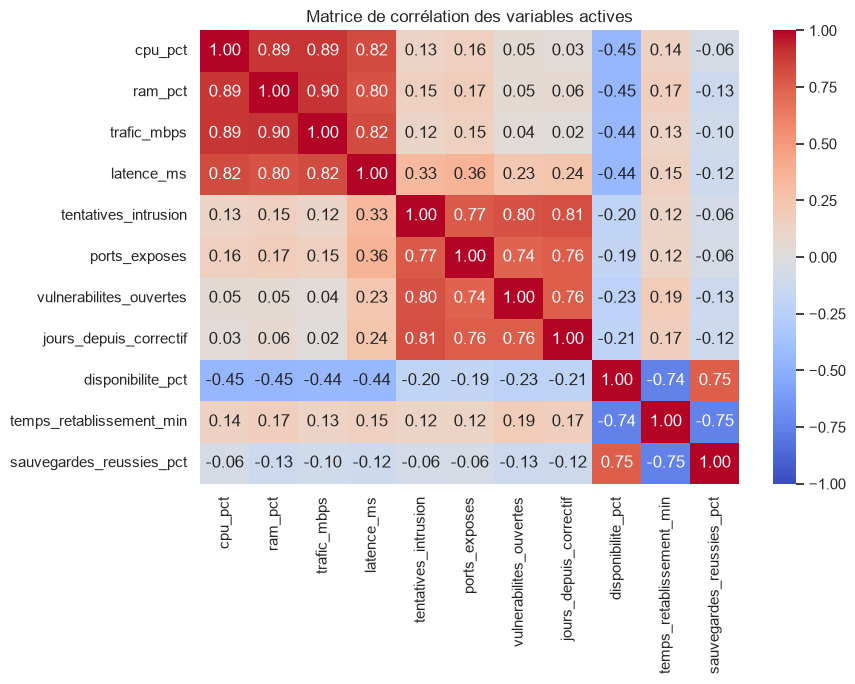

In [6]:
corr_matrix = X.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matrice de corrélation des variables actives")
plt.tight_layout()
plt.savefig("figures/fig_q2_matrice_correlation.png", dpi=150)
plt.show()

In [7]:
# Paires de variables les plus corrélées, en valeur absolue (hors diagonale)
corr_pairs = (
    corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .rename("correlation")
    .reset_index()
    .rename(columns={"level_0": "variable_1", "level_1": "variable_2"})
)
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
corr_pairs = corr_pairs.sort_values("abs_correlation", ascending=False)

corr_pairs.head(10)

,variable_1,variable_2,correlation,abs_correlation
13,ram_pct,trafic_mbps,0.898807,0.898807
1,cpu_pct,ram_pct,0.893409,0.893409
2,cpu_pct,trafic_mbps,0.890782,0.890782
3,cpu_pct,latence_ms,0.821252,0.821252
25,trafic_mbps,latence_ms,0.820685,0.820685
51,tentatives_intrusion,jours_depuis_correctif,0.813419,0.813419
50,tentatives_intrusion,vulnerabilites_ouvertes,0.803073,0.803073
14,ram_pct,latence_ms,0.798269,0.798269
49,tentatives_intrusion,ports_exposes,0.768137,0.768137
62,ports_exposes,jours_depuis_correctif,0.764334,0.764334


**Lecture :** deux groupes de variables fortement corrélées se dégagent nettement :
- **Charge / performance** : `cpu_pct`, `ram_pct`, `trafic_mbps`, `latence_ms` (corrélations ≈ 0.80–0.90) — un serveur chargé en CPU/RAM a aussi plus de trafic et plus de latence.
- **Exposition / sécurité** : `tentatives_intrusion`, `jours_depuis_correctif`, `vulnerabilites_ouvertes`, `ports_exposes` (corrélations ≈ 0.76–0.81) — un serveur mal corrigé (patché depuis longtemps) tend à cumuler plus de ports exposés, de vulnérabilités et de tentatives d'intrusion.

Ces deux blocs de corrélations sont un bon indice qu'il existera au moins deux axes principaux structurants — à vérifier en Question 3.

## Question 3 — Réalisation de l'ACP, éboulis, variance cumulée

On standardise `X` (`StandardScaler`, moyenne 0 / écart-type 1 par variable) puis on ajuste une ACP à 11 composantes (le maximum possible = nombre de variables). Comme les données sont standardisées, les **valeurs propres** de `pca.explained_variance_` sont exactement les valeurs propres de la **matrice de corrélation**.

Trois critères pour choisir le nombre d'axes à retenir :
- **Kaiser (>1)** : un axe n'est « utile » que s'il capte plus de variance qu'une variable originale (qui, standardisée, porte une variance de 1).
- **Seuil 80 %** : nombre d'axes nécessaires pour cumuler au moins 80 % de la variance totale.
- **Coude (elbow)** : rupture visuelle dans la décroissance des valeurs propres sur l'éboulis — au-delà, les axes n'apportent plus que du bruit résiduel.

In [8]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

n_obs, n_vars = X_scaled.shape
pca = PCA(n_components=n_vars, random_state=RANDOM_STATE)
scores = pca.fit_transform(X_scaled)  # coordonnées des 160 serveurs sur les 11 axes

eigenvalues = pca.explained_variance_
explained_ratio = pca.explained_variance_ratio_
cum_ratio = np.cumsum(explained_ratio)

scree_df = pd.DataFrame({
    "axe": [f"CP{i+1}" for i in range(n_vars)],
    "valeur_propre": eigenvalues,
    "variance_expliquee_%": explained_ratio * 100,
    "variance_cumulee_%": cum_ratio * 100,
})
scree_df

,axe,valeur_propre,variance_expliquee_%,variance_cumulee_%
0,CP1,4.567939,41.267177,41.267177
1,CP2,2.941134,26.570471,67.837649
2,CP3,2.094605,18.922849,86.760497
3,CP4,0.271219,2.450220,89.210717
4,CP5,0.256070,2.313361,91.524078
5,CP6,0.232893,2.103980,93.628058
6,CP7,0.185247,1.673538,95.301596
7,CP8,0.172222,1.555868,96.857464
8,CP9,0.160032,1.445743,98.303207
9,CP10,0.103382,0.933962,99.237169


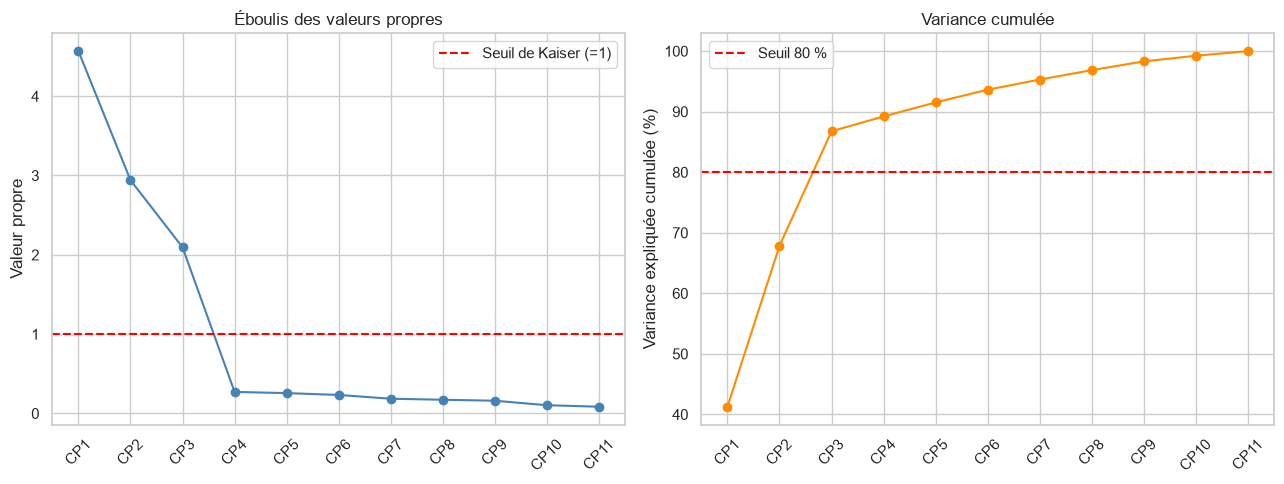

Nombre d'axes retenus - critère de Kaiser (valeur propre > 1) : 3
Nombre d'axes retenus - seuil de 80% de variance cumulée      : 3


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(scree_df["axe"], eigenvalues, "o-", color="steelblue")
axes[0].axhline(1, color="red", linestyle="--", label="Seuil de Kaiser (=1)")
axes[0].set_title("Éboulis des valeurs propres")
axes[0].set_ylabel("Valeur propre")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

axes[1].plot(scree_df["axe"], cum_ratio * 100, "o-", color="darkorange")
axes[1].axhline(80, color="red", linestyle="--", label="Seuil 80 %")
axes[1].set_title("Variance cumulée")
axes[1].set_ylabel("Variance expliquée cumulée (%)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/fig_q3_eboulis_variance_cumulee.png", dpi=150)
plt.show()

n_kaiser = int((eigenvalues > 1).sum())
n_80 = int(np.argmax(cum_ratio >= 0.80) + 1)
print(f"Nombre d'axes retenus - critère de Kaiser (valeur propre > 1) : {n_kaiser}")
print(f"Nombre d'axes retenus - seuil de 80% de variance cumulée      : {n_80}")

**Résultats :** CP1 = 41.3 %, CP2 = 26.6 %, CP3 = 18.9 % de variance expliquée, soit **86.8 % cumulés** sur les 3 premiers axes. La valeur propre chute ensuite fortement (CP4 = 0.27, contre CP3 = 2.10) : c'est une rupture nette sur l'éboulis (lecture du coude après CP3).

Les trois critères **convergent parfaitement** ici :
- Kaiser (valeur propre > 1) → **3 axes** (CP1, CP2, CP3 ont des valeurs propres de 4.57 / 2.94 / 2.10 ; CP4 tombe à 0.27)
- Seuil 80 % → **3 axes** suffisent (86.8 % cumulés)
- Coude → rupture visuelle nette après CP3

**Choix retenu : 3 axes (CP1, CP2, CP3).** L'objectif étant l'interprétation (comprendre la structure des indicateurs, pas juste comprimer les données), 3 axes restent lisibles individuellement tout en couvrant l'essentiel de l'information (86.8 %) — on retient donc ce nombre pour la suite du notebook.

## Question 4 — Corrélations variables–axes et contributions

Deux notions différentes, souvent confondues :
- **Corrélation variable–axe** (*loading*) : `corr(variable, CPk) = eigenvector_jk × √(valeur_propre_k)`. C'est la coordonnée de la variable dans le cercle des corrélations, entre -1 et 1.
- **Contribution** (%) : part de l'inertie d'un axe apportée par chaque variable = `eigenvector_jk² × 100`. Par construction, la somme des contributions sur un axe donné vaut 100 %.

⚠️ **Le signe des composantes est arbitraire** (une ACP ne distingue pas un axe de son opposé) : seule l'interprétation *relative* des signes entre variables sur un même axe a un sens (deux variables de même signe varient ensemble sur cet axe, deux variables de signe opposé varient en sens contraire).

In [10]:
n_axes = 3
components = pca.components_  # shape (11, 11), une ligne par axe

# Corrélations variables-axes (loadings)
loadings = (components[:n_axes, :] * np.sqrt(eigenvalues[:n_axes, None])).T
loadings_df = pd.DataFrame(loadings, index=X.columns, columns=[f"CP{i+1}" for i in range(n_axes)])

print("Corrélations variables-axes (cercle des corrélations) :")
loadings_df.round(3)

Corrélations variables-axes (cercle des corrélations) :


,CP1,CP2,CP3
cpu_pct,0.747,-0.544,0.269
ram_pct,0.761,-0.528,0.229
trafic_mbps,0.742,-0.556,0.259
latence_ms,0.829,-0.312,0.277
tentatives_intrusion,0.606,0.684,0.188
ports_exposes,0.611,0.632,0.209
vulnerabilites_ouvertes,0.549,0.724,0.068
jours_depuis_correctif,0.548,0.736,0.090
disponibilite_pct,-0.699,0.161,0.614
temps_retablissement_min,0.453,-0.001,-0.800


In [11]:
# Contributions (%) des variables aux 3 premiers axes
contrib = (components[:n_axes, :] ** 2 * 100).T
contrib_df = pd.DataFrame(contrib, index=X.columns, columns=[f"CP{i+1}" for i in range(n_axes)])

print("Contributions (%) des variables aux axes (somme = 100% par colonne) :")
print(contrib_df.sum().round(2))
contrib_df.round(2)

Contributions (%) des variables aux axes (somme = 100% par colonne) :
CP1    100.0
CP2    100.0
CP3    100.0
dtype: float64


,CP1,CP2,CP3
cpu_pct,12.21,10.06,3.44
ram_pct,12.68,9.49,2.50
trafic_mbps,12.06,10.51,3.20
latence_ms,15.05,3.31,3.65
tentatives_intrusion,8.05,15.90,1.69
ports_exposes,8.18,13.59,2.08
vulnerabilites_ouvertes,6.60,17.84,0.22
jours_depuis_correctif,6.58,18.40,0.39
disponibilite_pct,10.70,0.88,18.03
temps_retablissement_min,4.50,0.00,30.59


**Interprétation (en gardant à l'esprit que le signe est arbitraire) :**

- **CP1 (41.3 %)** : quasiment toutes les variables chargent positivement (0.55 à 0.83) **sauf** `disponibilite_pct` (-0.70) et `sauvegardes_reussies_pct` (-0.39). CP1 est un axe global qui oppose « charge + exposition + incidents » d'un côté à « résilience/disponibilité » de l'autre : un score élevé signale un serveur simultanément chargé, exposé et peu résilient.
- **CP2 (26.6 %)** : oppose nettement le bloc **charge/performance** (`cpu_pct`, `ram_pct`, `trafic_mbps`, `latence_ms`, loadings négatifs -0.31 à -0.56) au bloc **exposition/sécurité** (`tentatives_intrusion`, `ports_exposes`, `vulnerabilites_ouvertes`, `jours_depuis_correctif`, loadings positifs 0.63 à 0.74). CP2 différencie donc le *type* de stress dominant d'un serveur : plutôt surcharge, ou plutôt exposition/sécurité.
- **CP3 (18.9 %)** : dominé par les trois variables de **résilience/sauvegarde** — `sauvegardes_reussies_pct` (0.85, contribution 34.2 %), `temps_retablissement_min` (-0.80, contribution 30.6 %) et `disponibilite_pct` (0.61, contribution 18.0 %) — qui à elles seules expliquent **82.8 %** de cet axe. CP3 est donc un axe de **résilience opérationnelle**, largement indépendant de CP1 et CP2.

## Question 5 — Cercle des corrélations et carte thermique

Le **cercle des corrélations** place chaque variable à ses coordonnées `(loading_CP1, loading_CP2)` : plus une flèche est proche du cercle unité, mieux la variable est représentée dans ce plan ; deux flèches proches (même direction) indiquent des variables corrélées.

Pour CP1–CP3 (deux axes moins intuitifs à représenter ensemble visuellement côte à côte avec CP1-CP2), on utilise plutôt une **carte thermique** des loadings.

**Contribution vs cos² :** la contribution (Q4) mesure le poids d'une variable dans la construction d'un axe (somme à 100 % par axe). Le **cos²** mesure la qualité de représentation d'une variable dans un plan : `cos²_plan = loading_CP_i² + loading_CP_j²` (borné à 1). Une variable peut fortement contribuer à un axe tout en étant, une fois combinée à l'autre axe, mal représentée dans le plan — et inversement.

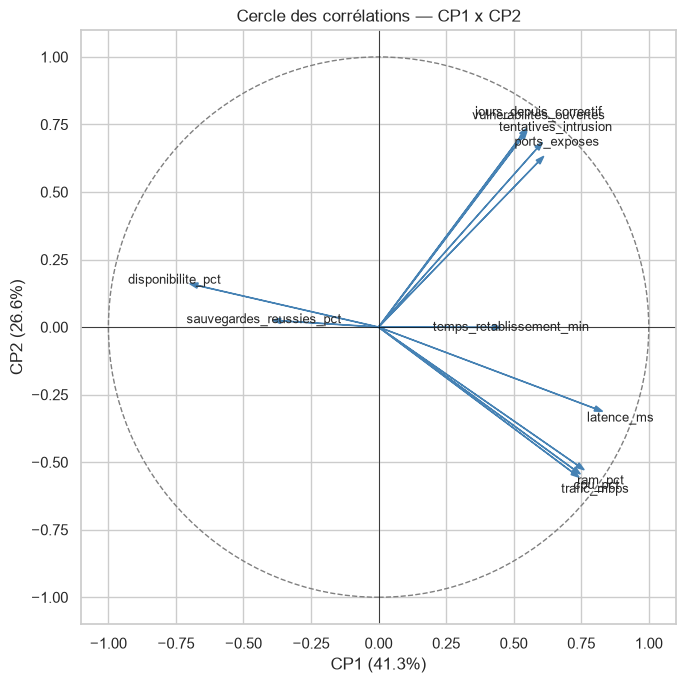

In [12]:
fig, ax = plt.subplots(figsize=(7, 7))
circle = plt.Circle((0, 0), 1, facecolor="none", edgecolor="grey", linestyle="--")
ax.add_patch(circle)

for var in loadings_df.index:
    x_, y_ = loadings_df.loc[var, "CP1"], loadings_df.loc[var, "CP2"]
    ax.arrow(0, 0, x_, y_, head_width=0.02, length_includes_head=True, color="steelblue")
    ax.text(x_ * 1.08, y_ * 1.08, var, fontsize=9, ha="center", va="center")

ax.axhline(0, color="black", linewidth=0.5)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlim(-1.1, 1.1)
ax.set_ylim(-1.1, 1.1)
ax.set_xlabel(f"CP1 ({explained_ratio[0]*100:.1f}%)")
ax.set_ylabel(f"CP2 ({explained_ratio[1]*100:.1f}%)")
ax.set_title("Cercle des corrélations — CP1 x CP2")
ax.set_aspect("equal")
plt.tight_layout()
plt.savefig("figures/fig_q5_cercle_correlations_cp1_cp2.png", dpi=150)
plt.show()

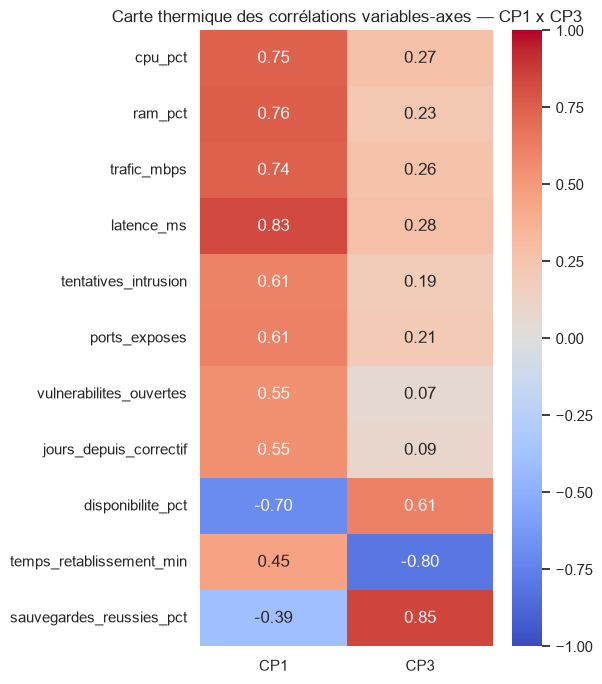

In [13]:
plt.figure(figsize=(6, 7))
sns.heatmap(loadings_df[["CP1", "CP3"]], annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Carte thermique des corrélations variables-axes — CP1 x CP3")
plt.tight_layout()
plt.savefig("figures/fig_q5_heatmap_cp1_cp3.png", dpi=150)
plt.show()

In [14]:
# cos² de représentation des variables dans chaque plan (somme des loadings² des 2 axes du plan)
cos2_vars = pd.DataFrame({
    "cos2_CP1_CP2": loadings_df["CP1"] ** 2 + loadings_df["CP2"] ** 2,
    "cos2_CP1_CP3": loadings_df["CP1"] ** 2 + loadings_df["CP3"] ** 2,
})
cos2_vars.round(3)

,cos2_CP1_CP2,cos2_CP1_CP3
cpu_pct,0.854,0.630
ram_pct,0.858,0.632
trafic_mbps,0.860,0.618
latence_ms,0.785,0.764
tentatives_intrusion,0.835,0.403
ports_exposes,0.774,0.417
vulnerabilites_ouvertes,0.826,0.306
jours_depuis_correctif,0.842,0.309
disponibilite_pct,0.515,0.866
temps_retablissement_min,0.206,0.846


**Lecture :** `temps_retablissement_min` et `sauvegardes_reussies_pct` sont **mal représentées dans le plan CP1–CP2** (cos² = 0.21 et 0.16 — leurs flèches sont proches du centre du cercle, pas du bord) alors qu'elles contribuent fortement à CP3 (Q4) et sont **très bien représentées dans le plan CP1–CP3** (cos² = 0.85 et 0.87). C'est la preuve visuelle directe que le plan CP1–CP2 seul **occulte la dimension résilience/sauvegardes** de ces serveurs, et qu'il faut regarder CP3 pour la voir — un exemple concret où contribution élevée à un axe (Q4) et bonne représentation dans un plan donné (cos²) sont deux choses distinctes.

## Question 6 — Projection des individus, cos² individuels

On projette les 160 serveurs sur le plan CP1–CP2 (leurs scores, déjà calculés dans `scores`), colorés par `segment_synthetique` (variable externe, non utilisée dans l'ACP — simple grille de lecture a posteriori).

Le **cos² d'un individu** dans un plan mesure la part de sa distance totale à l'origine (dans l'espace standardisé à 11 dimensions) expliquée par ce plan :

`cos²_i(plan) = (score_i,CP1² + score_i,CP2²) / distance_totale_i²`

avec `distance_totale_i² = somme des score_i,k² sur les 11 axes` (= somme des 11 variables standardisées au carré pour ce serveur, la rotation ACP préserve les distances). Un cos² proche de 1 → le plan CP1-CP2 représente fidèlement la position de ce serveur ; un cos² proche de 0 → sa position réelle est ailleurs (sur CP3 ou au-delà), et le lire sur ce plan seul est trompeur.

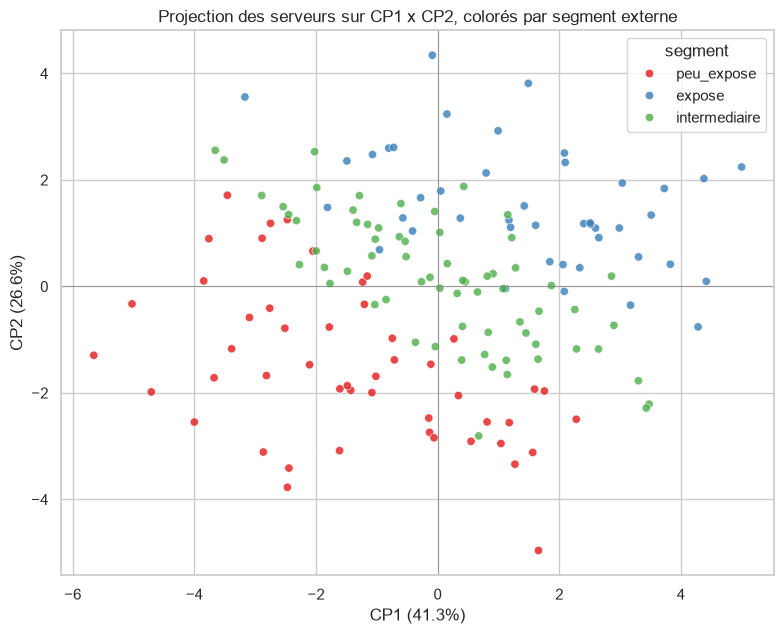

In [15]:
ind_df = pd.DataFrame(scores[:, :3], columns=["CP1", "CP2", "CP3"], index=df.index)
ind_df["serveur_id"] = id_col
ind_df["segment"] = segment_col

plt.figure(figsize=(8, 6.5))
sns.scatterplot(data=ind_df, x="CP1", y="CP2", hue="segment", palette="Set1", alpha=0.8)
plt.axhline(0, color="grey", linewidth=0.5)
plt.axvline(0, color="grey", linewidth=0.5)
plt.xlabel(f"CP1 ({explained_ratio[0]*100:.1f}%)")
plt.ylabel(f"CP2 ({explained_ratio[1]*100:.1f}%)")
plt.title("Projection des serveurs sur CP1 x CP2, colorés par segment externe")
plt.tight_layout()
plt.savefig("figures/fig_q6_projection_individus_cp1_cp2.png", dpi=150)
plt.show()

In [16]:
d2_total = (scores ** 2).sum(axis=1)  # distance² totale à l'origine, espace standardisé complet (11 axes)
ind_df["distance_totale"] = np.sqrt(d2_total)
ind_df["cos2_CP1_CP2"] = (scores[:, 0] ** 2 + scores[:, 1] ** 2) / d2_total

print(f"cos²(CP1-CP2) : min={ind_df['cos2_CP1_CP2'].min():.3f}  "
      f"moyenne={ind_df['cos2_CP1_CP2'].mean():.3f}  max={ind_df['cos2_CP1_CP2'].max():.3f}")
print()
print("5 serveurs les moins bien représentés dans le plan CP1-CP2 (cos² le plus faible) :")
ind_df.nsmallest(5, "cos2_CP1_CP2")[["serveur_id", "segment", "distance_totale", "cos2_CP1_CP2"]]

cos²(CP1-CP2) : min=0.003  moyenne=0.597  max=0.972

5 serveurs les moins bien représentés dans le plan CP1-CP2 (cos² le plus faible) :


,serveur_id,segment,distance_totale,cos2_CP1_CP2
115,SRV-116,intermediaire,0.963121,0.002783
150,SRV-151,intermediaire,2.690497,0.006155
148,SRV-149,intermediaire,1.876199,0.022110
124,SRV-125,intermediaire,2.997528,0.023205
26,SRV-027,intermediaire,1.727117,0.040597


**Lecture :** le cos²(CP1-CP2) varie énormément selon les serveurs (de 0.003 à 0.97, moyenne 0.60). Les serveurs `SRV-116`, `SRV-151`, `SRV-149`, `SRV-125`, `SRV-027` (cos² < 0.05, tous étiquetés `intermediaire`) **ne doivent pas être interprétés avec confiance à partir du seul plan CP1–CP2** : leur position réelle dans l'espace à 11 dimensions est largement portée par CP3 (résilience/sauvegardes) ou des axes suivants, invisibles sur ce graphique. Pour ces serveurs précis, il faut se référer au plan CP1–CP3 (ou à leurs coordonnées CP3 directement) avant de tirer une quelconque conclusion sur leur profil.

## Question 7 — Individus les plus éloignés de l'origine

On compare deux façons de repérer les serveurs « atypiques » :
1. **Distance dans l'espace standardisé complet** (11 axes) : `distance_totale` déjà calculée en Q6 — c'est la vraie distance multivariée, elle ne perd aucune information.
2. **Distance apparente dans le seul plan CP1–CP2** : `sqrt(score_CP1² + score_CP2²)` — ce que montrerait un graphique 2D classique.

In [17]:
ind_df["distance_CP1_CP2"] = np.sqrt(scores[:, 0] ** 2 + scores[:, 1] ** 2)

top5_full = ind_df.nlargest(5, "distance_totale")[["serveur_id", "segment", "distance_totale"]]
top5_plan = ind_df.nlargest(5, "distance_CP1_CP2")[["serveur_id", "segment", "distance_CP1_CP2"]]

print("5 serveurs les plus éloignés — espace standardisé complet (11 axes) :")
print(top5_full.to_string(index=False))
print()
print("5 serveurs les plus éloignés — plan CP1-CP2 seulement :")
print(top5_plan.to_string(index=False))
print()
overlap = set(top5_full["serveur_id"]) & set(top5_plan["serveur_id"])
print(f"Serveurs communs aux deux classements : {sorted(overlap)} ({len(overlap)}/5)")

5 serveurs les plus éloignés — espace standardisé complet (11 axes) :
serveur_id    segment  distance_totale
   SRV-145 peu_expose         5.966867
   SRV-150 peu_expose         5.850098
   SRV-117     expose         5.589982
   SRV-073 peu_expose         5.362644
   SRV-110 peu_expose         5.267610

5 serveurs les plus éloignés — plan CP1-CP2 seulement :
serveur_id    segment  distance_CP1_CP2
   SRV-145 peu_expose          5.798344
   SRV-117     expose          5.478801
   SRV-073 peu_expose          5.229870
   SRV-129 peu_expose          5.106516
   SRV-071 peu_expose          5.034950

Serveurs communs aux deux classements : ['SRV-073', 'SRV-117', 'SRV-145'] (3/5)


**Comparaison :** seuls 3 des 5 serveurs sont communs aux deux classements (`SRV-145`, `SRV-117`, `SRV-073`) ; `SRV-150` et `SRV-110`, pourtant parmi les plus éloignés dans l'espace complet, sortent du top 5 quand on ne regarde que CP1–CP2 (remplacés par `SRV-129` et `SRV-071`, qui eux sont plus « visibles » sur ce plan mais moins extrêmes globalement). Se limiter à CP1–CP2 (86.8 % de variance certes, mais pas 100 %) fait donc manquer une partie des individus réellement atypiques — cohérent avec le constat de la Question 6 (`SRV-150` a justement un cos²(CP1-CP2) modéré malgré une grande distance totale).

**Pourquoi une distance élevée ne signifie pas un incident de sécurité :**
- La distance agrège les 11 indicateurs standardisés **sans distinction de nature** : un serveur peut être loin de l'origine parce qu'il cumule charge + exposition + faible résilience (profil CP1 « à risque »), mais aussi simplement parce qu'il a des **sauvegardes exceptionnellement bonnes** ou une disponibilité inhabituellement élevée — des écarts positifs, pas des anomalies opérationnelles.
- Une grande distance ne dit rien sur la **direction** de l'écart ni sur quelle variable en est responsable ; il faut redescendre aux variables d'origine (ou aux contributions/coordonnées par axe) pour interpréter *pourquoi*.
- Les données sont **synthétiques** : aucun incident réel n'est associé à ces valeurs. La distance signale une position atypique statistiquement, pas un diagnostic de sécurité.

## Question 8 — Reconstruction et erreur quadratique moyenne

Avec `k` axes, on reconstruit une approximation des données standardisées : `X_reconstruit = scores[:, :k] @ components[:k, :]`. L'erreur quadratique moyenne (MSE, moyennée sur les 160×11 valeurs) mesure l'information perdue en ne gardant que `k` axes sur 11.

Convention de standardisation utilisée ici : chaque variable standardisée a une variance totale de 1 ; la variance totale du jeu de données vaut donc `p = 11` (somme des variances), répartie exactement selon les valeurs propres (somme des valeurs propres = 11). Sous cette convention, l'identité théorique est :

`MSE(k) = 1 - variance_expliquee_cumulee(k)`

In [18]:
def reconstruction_mse(k):
    X_hat = scores[:, :k] @ components[:k, :]
    return np.mean((X_scaled.values - X_hat) ** 2)

recon_rows = []
for k in [2, 3, 4]:
    mse = reconstruction_mse(k)
    theorique = 1 - cum_ratio[k - 1]
    recon_rows.append({"k_axes": k, "MSE": mse, "1_moins_variance_cumulee": theorique, "ecart": abs(mse - theorique)})

recon_df = pd.DataFrame(recon_rows)
recon_df

,k_axes,MSE,1_moins_variance_cumulee,ecart
0,2,0.321624,0.321624,1.110223e-16
1,3,0.132395,0.132395,1.665335e-16
2,4,0.107893,0.107893,1.804112e-16


**Vérification :** avec k=2 axes, MSE = 0.3216 = 1 − 0.6784 (variance cumulée CP1+CP2) ; avec k=3, MSE = 0.1324 = 1 − 0.8676 ; avec k=4, MSE = 0.1079 = 1 − 0.8921. L'écart est nul (à l'erreur flottante près) dans les trois cas : l'identité `MSE(k) = 1 - variance_expliquee_cumulee(k)` est confirmée numériquement. Cela illustre concrètement le rôle des axes non retenus : l'information qu'on « perd » en gardant 3 axes (13.2 %) est exactement l'énergie portée par CP4 à CP11.

## Question 9 — Comparaison des plans, conclusion

On trace le plan CP1–CP3 (même logique qu'en Q6) pour le comparer visuellement au plan CP1–CP2.

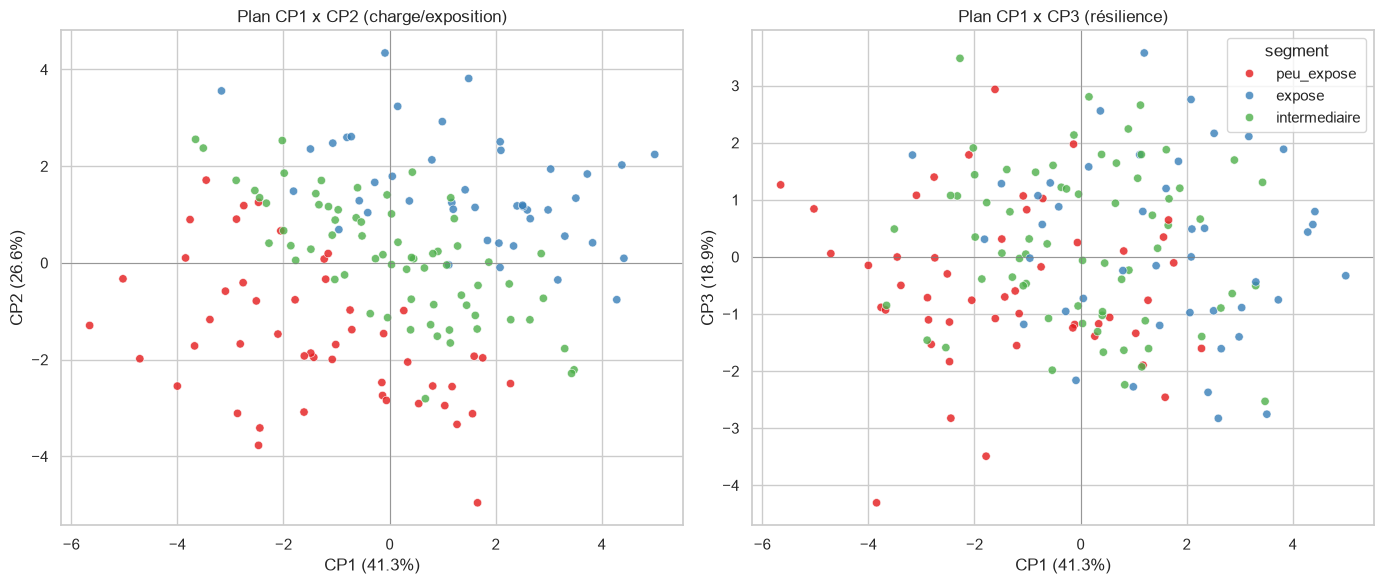

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(data=ind_df, x="CP1", y="CP2", hue="segment", palette="Set1", alpha=0.8, ax=axes[0], legend=False)
axes[0].axhline(0, color="grey", linewidth=0.5)
axes[0].axvline(0, color="grey", linewidth=0.5)
axes[0].set_title("Plan CP1 x CP2 (charge/exposition)")
axes[0].set_xlabel(f"CP1 ({explained_ratio[0]*100:.1f}%)")
axes[0].set_ylabel(f"CP2 ({explained_ratio[1]*100:.1f}%)")

sns.scatterplot(data=ind_df, x="CP1", y="CP3", hue="segment", palette="Set1", alpha=0.8, ax=axes[1])
axes[1].axhline(0, color="grey", linewidth=0.5)
axes[1].axvline(0, color="grey", linewidth=0.5)
axes[1].set_title("Plan CP1 x CP3 (résilience)")
axes[1].set_xlabel(f"CP1 ({explained_ratio[0]*100:.1f}%)")
axes[1].set_ylabel(f"CP3 ({explained_ratio[2]*100:.1f}%)")

plt.tight_layout()
plt.savefig("figures/fig_q9_comparaison_plans.png", dpi=150)
plt.show()

In [20]:
# Position moyenne (CP1, CP2, CP3) par segment externe
ind_df.groupby("segment")[["CP1", "CP2", "CP3"]].agg(["mean", "std"]).round(2)

CP1         CP2         CP3      
               mean   std  mean   std  mean   std
segment                                          
expose         1.50  1.89  1.50  1.12  0.18  1.55
intermediaire  0.06  1.69  0.12  1.22  0.24  1.37
peu_expose    -1.43  1.96 -1.52  1.46 -0.49  1.37

**Comparaison des deux plans :** le plan CP1–CP2 sépare nettement les trois segments externes (`expose` en haut-droite, `peu_expose` en bas-gauche, `intermediaire` au centre — moyennes CP1/CP2 de -1.4/-1.5 à +1.5/+1.5), avec de fortes contributions des variables charge et exposition. Sur le plan CP1–CP3, en revanche, les trois segments se **superposent presque totalement** (moyennes CP3 proches de 0 : -0.49, 0.24, 0.18, avec des écarts-types intra-groupe supérieurs à l'écart entre les moyennes) : CP3 n'apporte quasiment aucune information sur ce découpage.

**Rôle des variables de résilience et de sauvegarde :** `disponibilite_pct`, `temps_retablissement_min` et `sauvegardes_reussies_pct` structurent presque exclusivement CP3 (Q4, 82.8 % de l'inertie de cet axe) et sont mal représentées sur CP1–CP2 (Q5, cos² < 0.22). Or `segment_synthetique` ne semble pas construit à partir de cette dimension : la résilience/sauvegardes est donc une **dimension d'information orthogonale** à ce que capture le segment externe — un serveur peut être `peu_expose` (faible charge, faible exposition) tout en ayant une résilience très variable, et inversement. Ignorer CP3 reviendrait à ignorer complètement cet aspect du profil des serveurs.

**Conclusion prudente sur l'usage de l'ACP en audit informatique :** l'ACP révèle ici une structure claire et stable (3 axes interprétables, 86.8 % de variance, deux blocs de corrélation confirmés) qui **résume** les 11 indicateurs en trois dimensions de lecture : charge/risque global (CP1), type de stress dominant charge vs sécurité (CP2), résilience/sauvegardes (CP3). C'est un outil **descriptif et exploratoire** — il organise l'information et suggère où regarder en priorité (ex. serveurs à distance totale élevée, ou mal représentés sur CP1-CP2 donc à vérifier via CP3). Ce n'est en revanche **ni un outil de diagnostic causal ni un détecteur d'incident** : une position atypique ne prouve rien en soi (Q7), les données sont synthétiques, et aucune validation contre un événement de sécurité réel n'a été effectuée. L'ACP oriente la vérification opérationnelle, elle ne la remplace pas.